# TP — Benchmark CPU vs GPU sur opérations vectorielles

**Binôme :** Hajar En-Najdy & Mohamed Akrame Kraichy

**Objectif :** comparer les performances de la **somme**, du **produit scalaire** et de la **norme**
sur **CPU** et **GPU**, pour des vecteurs de **1 000 à 100 000 000** éléments, avec PyTorch.

> Ce notebook fonctionne **partout** : Google Colab, PC avec GPU NVIDIA, et Mac Apple Silicon.
> Il détecte automatiquement le matériel disponible. Voir `INSTALLATION.md` pour préparer ton
> environnement avant de lancer.

## 0. Détection automatique du matériel

PyTorch peut calculer sur trois types de processeurs :
- **CUDA** : GPU NVIDIA (PC/portable avec carte NVIDIA, ou Google Colab).
- **MPS** : GPU intégré des Mac Apple Silicon (M1/M2/M3).
- **CPU** : le processeur classique, toujours disponible.

La cellule ci-dessous choisit automatiquement le meilleur accélérateur présent. **Aucune
modification à faire selon ta machine** : c'est le même notebook pour tout le monde.

In [1]:
import torch

device_cpu = torch.device("cpu")
accel_name = "Aucun"
device_accel = None
accel_type = None

if torch.cuda.is_available():
    device_accel = torch.device("cuda")
    accel_type = "cuda"
    accel_name = torch.cuda.get_device_name(0)
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device_accel = torch.device("mps")
    accel_type = "mps"
    accel_name = "Apple Silicon (MPS)"

print("Version PyTorch    :", torch.__version__)
print("Accélérateur       :", accel_type if accel_type else "aucun (CPU seul)")
print("Nom du matériel    :", accel_name)
if accel_type == "cuda":
    print("Mémoire GPU        :", round(torch.cuda.get_device_properties(0).total_memory/1e9,2), "Go")
elif accel_type is None:
    print(">> Aucun GPU détecté : le notebook tournera en CPU uniquement.")
    print(">> Sur Colab : Exécution -> Modifier le type d'exécution -> GPU.")

Version PyTorch    : 2.11.0+cu128
Accélérateur       : cuda
Nom du matériel    : Tesla T4
Mémoire GPU        : 15.64 Go


## 1. Fonction de synchronisation universelle

Pour mesurer correctement, il faut **attendre la fin réelle** du calcul sur l'accélérateur.
La commande diffère selon le matériel : `torch.cuda.synchronize()` pour NVIDIA,
`torch.mps.synchronize()` pour Mac. On encapsule ça dans une seule fonction `sync()` qui
fait ce qu'il faut selon le device détecté.

In [2]:
def sync():
    """Force l'attente de la fin du calcul sur l'accélérateur courant."""
    if accel_type == "cuda":
        torch.cuda.synchronize()
    elif accel_type == "mps":
        torch.mps.synchronize()
    # sur CPU : rien à synchroniser

## 2. Mesure du temps (warm-up + synchronisation + médiane)

Trois précautions pour des mesures fiables :
- **Warm-up** : on exécute quelques fois sans mesurer (la 1ʳᵉ exécution est plus lente).
- **Synchronisation** : sans elle, on mesurerait le temps de *lancer* le calcul, pas de le *faire*.
- **Médiane** : robuste face à une mesure ponctuellement perturbée par le système.

In [3]:
import time

def benchmark(fonction, n_repet=10, warmup=3, use_accel=False):
    """Temps médian (ms) d'une fonction sans argument."""
    for _ in range(warmup):
        fonction()
    if use_accel:
        sync()

    temps = []
    for _ in range(n_repet):
        debut = time.perf_counter()
        fonction()
        if use_accel:
            sync()
        temps.append((time.perf_counter() - debut) * 1000)

    temps.sort()
    return temps[len(temps) // 2]

## 3. Les trois opérations vectorielles

- **Somme** : `Σ aᵢ` (lit 1 vecteur)
- **Produit scalaire** : `a·b = Σ aᵢbᵢ` (lit 2 vecteurs)
- **Norme** : `‖a‖ = √(Σ aᵢ²)` (lit 1 vecteur)

In [4]:
def op_somme(a, b):            return torch.sum(a)
def op_produit_scalaire(a, b): return torch.dot(a, b)
def op_norme(a, b):            return torch.norm(a)

OPERATIONS = {
    "Somme": op_somme,
    "Produit scalaire": op_produit_scalaire,
    "Norme": op_norme,
}

## 4. Tailles testées et poids mémoire

Un `float32` = 4 octets. Un vecteur de 100M éléments pèse 400 Mo. On vérifie que tout tient
en mémoire avant de lancer les mesures.

In [5]:
TAILLES = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]

for n in TAILLES:
    print(f"{n:>12,} éléments  ->  {n*4/1e6:8.1f} Mo par vecteur")

       1,000 éléments  ->       0.0 Mo par vecteur
      10,000 éléments  ->       0.0 Mo par vecteur
     100,000 éléments  ->       0.4 Mo par vecteur
   1,000,000 éléments  ->       4.0 Mo par vecteur
  10,000,000 éléments  ->      40.0 Mo par vecteur
 100,000,000 éléments  ->     400.0 Mo par vecteur


## 5. Boucle de mesure complète

Pour chaque taille, on mesure le CPU **et** l'accélérateur (s'il existe). Les données sont créées
directement sur le bon appareil **avant** le chrono : on mesure le calcul, pas le transfert.

In [6]:
resultats = []

for n in TAILLES:
    # --- CPU ---
    a_cpu = torch.rand(n, dtype=torch.float32, device=device_cpu)
    b_cpu = torch.rand(n, dtype=torch.float32, device=device_cpu)
    for nom_op, fonction in OPERATIONS.items():
        t = benchmark(lambda: fonction(a_cpu, b_cpu), use_accel=False)
        resultats.append({"taille": n, "operation": nom_op, "device": "CPU", "temps_ms": t})
    del a_cpu, b_cpu

    # --- Accélérateur (GPU NVIDIA ou Mac MPS) ---
    if device_accel is not None:
        a = torch.rand(n, dtype=torch.float32, device=device_accel)
        b = torch.rand(n, dtype=torch.float32, device=device_accel)
        for nom_op, fonction in OPERATIONS.items():
            t = benchmark(lambda: fonction(a, b), use_accel=True)
            resultats.append({"taille": n, "operation": nom_op, "device": "GPU", "temps_ms": t})
        del a, b
        if accel_type == "cuda":
            torch.cuda.empty_cache()

    print(f"Taille {n:>12,} terminée")

print("\nMesures terminées :", len(resultats), "lignes")

Taille        1,000 terminée
Taille       10,000 terminée
Taille      100,000 terminée
Taille    1,000,000 terminée
Taille   10,000,000 terminée
Taille  100,000,000 terminée

Mesures terminées : 36 lignes


## 6. Tableau et accélération (speedup)

Le **speedup** = temps_CPU / temps_GPU. > 1 : l'accélérateur gagne ; < 1 : le CPU gagne.

In [7]:
import pandas as pd

df = pd.DataFrame(resultats)
pivot = df.pivot_table(index=["operation","taille"], columns="device", values="temps_ms")
if "GPU" in pivot.columns:
    pivot["speedup (CPU/GPU)"] = pivot["CPU"] / pivot["GPU"]
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pivot

device                         CPU    GPU  speedup (CPU/GPU)
operation        taille                                     
Norme            1000       0.0057 0.0291             0.1943
                 10000      0.0074 0.0332             0.2239
                 100000     0.0258 0.0424             0.6090
                 1000000    0.2033 0.0385             5.2821
                 10000000   3.1905 0.1760            18.1294
                 100000000 33.9037 1.5013            22.5834
Produit scalaire 1000       0.0027 0.0259             0.1046
                 10000      0.0036 0.0270             0.1348
                 100000     0.0097 0.0266             0.3653
                 1000000    0.3306 0.0550             6.0150
                 10000000   5.0440 0.3241            15.5608
                 100000000 60.3430 3.1425            19.2024
Somme            1000       0.0036 0.0232             0.1554
                 10000      0.0040 0.0247             0.1607
                 100000     0.0076 0.0382             0.1983
                 1000000    0.1762 0.0372             4.7339
                 10000000   2.3382 0.1763            13.2620
                 100000000 33.4152 1.4977            22.3117

## 7. Graphique : temps en fonction de la taille (log-log)

Le point où la courbe GPU passe **sous** la courbe CPU est le **point de bascule**.

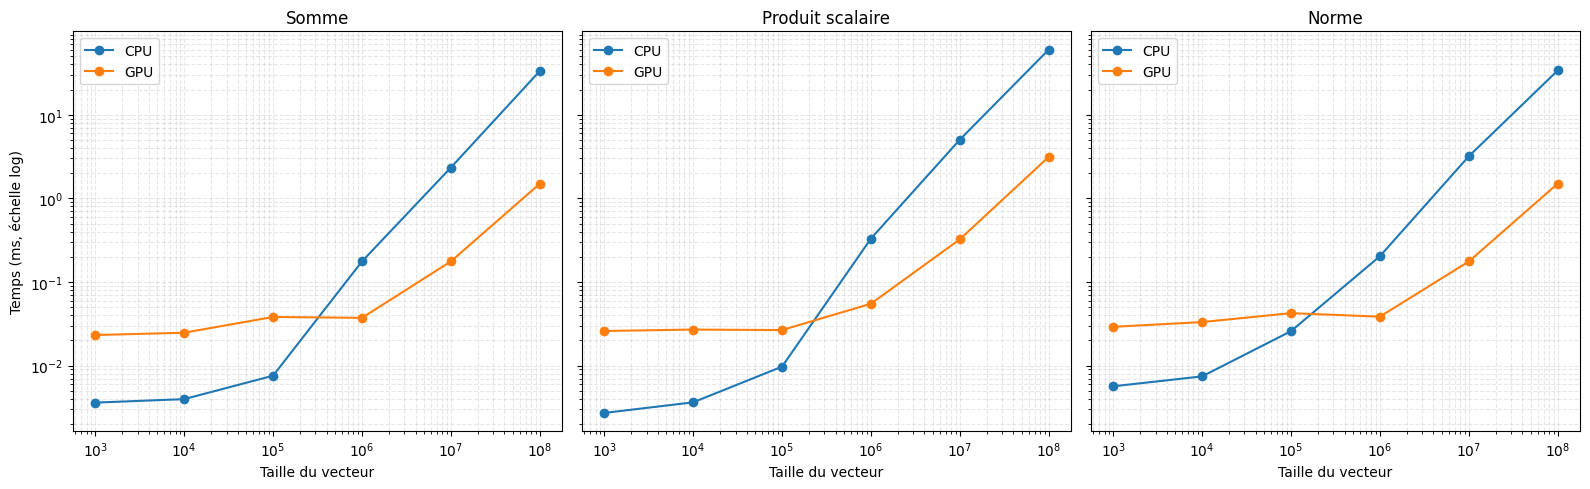

In [8]:
import matplotlib.pyplot as plt

operations = df["operation"].unique()
fig, axes = plt.subplots(1, len(operations), figsize=(16,5), sharey=True)
for ax, op in zip(axes, operations):
    sous = df[df["operation"]==op]
    for dev in sous["device"].unique():
        d = sous[sous["device"]==dev].sort_values("taille")
        ax.plot(d["taille"], d["temps_ms"], marker="o", label=dev)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(op); ax.set_xlabel("Taille du vecteur")
    ax.grid(True, which="both", ls="--", alpha=0.3); ax.legend()
axes[0].set_ylabel("Temps (ms, échelle log)")
plt.tight_layout(); plt.savefig("temps_vs_taille.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Graphique : speedup en fonction de la taille

La ligne rouge à y = 1 sépare la zone CPU gagnant (dessous) de la zone GPU gagnant (dessus).

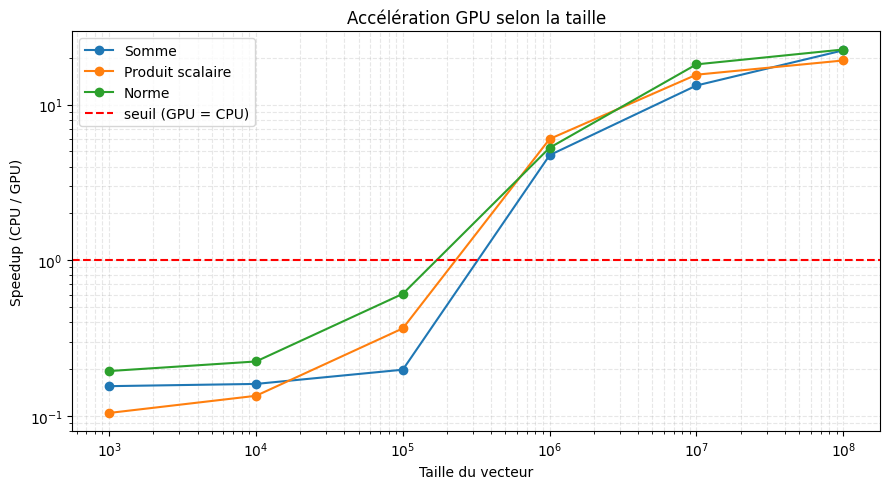

In [9]:
if device_accel is not None:
    fig, ax = plt.subplots(figsize=(9,5))
    for op in operations:
        sous = pivot.loc[op]
        ax.plot(sous.index, sous["speedup (CPU/GPU)"], marker="o", label=op)
    ax.axhline(1, color="red", ls="--", label="seuil (GPU = CPU)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Taille du vecteur"); ax.set_ylabel("Speedup (CPU / GPU)")
    ax.set_title("Accélération GPU selon la taille")
    ax.grid(True, which="both", ls="--", alpha=0.3); ax.legend()
    plt.tight_layout(); plt.savefig("speedup.png", dpi=150, bbox_inches="tight"); plt.show()
else:
    print("Pas d'accélérateur : section ignorée (mesures CPU uniquement).")

## 9. Export des résultats

Génère le CSV et les images à placer dans le dossier `results/` du dépôt.

In [10]:
df.to_csv("resultats.csv", index=False)
pivot.to_csv("resultats_pivot.csv")
print("Fichiers générés : resultats.csv, resultats_pivot.csv, temps_vs_taille.png, speedup.png")

Fichiers générés : resultats.csv, resultats_pivot.csv, temps_vs_taille.png, speedup.png


## 10. Conclusions à présenter

À compléter avec **vos** chiffres :
1. Petits vecteurs (1K–100K) : le CPU est souvent aussi rapide (coût fixe du lancement GPU).
2. Point de bascule : autour de ____ éléments, le GPU passe devant.
3. Grands vecteurs (10M–100M) : GPU nettement plus rapide (speedup ____ ×).
4. Le produit scalaire (2 vecteurs lus) avantage particulièrement le GPU.

**3 réflexes de benchmark :** synchroniser, warm-up, médiane.